# EEU4C16/EEP5C16 Lab 7 - Fast Single Image Super-Resolution

## Background
Super-resolution is a technique in image and video processing whereby a low resolution (LR) image/video frame is upsampled to a higher resolution (HR). This has numerous applications for:

- Balancing image/video quality and transmission efficiency for websites.

- Upscaling of photos taken on mobile devices ([Google Research Blog - Enhance! RAISR Sharp Images with Machine Learning](https://research.google/blog/enhance-raisr-sharp-images-with-machine-learning/)).

- Upscaling of video games ([NVIDIA - DLSS 4](https://www.nvidia.com/en-us/geforce/technologies/dlss/)).

Fast super-resolution is of utmost importance for real-time applications and a number of companies are looking into this: [Qualcomm - QuickSRNet: Plain Single-Image Super-Resolution Architecture for Faster Inference on Mobile Platforms](https://openaccess.thecvf.com/content/CVPR2023W/MobileAI/papers/Berger_QuickSRNet_Plain_Single-Image_Super-Resolution_Architecture_for_Faster_Inference_on_Mobile_CVPRW_2023_paper.pdf)

## Your Task
Train a super-resolution model to up-sample image patches from $32\times32$ to $128\times128$ (a factor of $\times4$) and get as close to real-time processing as possible (take this to mean processing a $30$ $fps$ video stream which means your model inference time should be close to $1/30$ seconds $~0.03$ $s$).

**Data Pre-Processing Requirements:**

1. You will be given a training dataset that is represenatitve of the target upsampling distribution (you may want to augment this with other datasets you can find online).

2. You will have to downsample these images and use them as input to the super-resolution neural network.

3. Generate an approriate training/test split from your dataset.

**Architecture Requirements:**

1. Design and train a deep neural network architecture that finds a tradeoff between speed and accuracy.

2. You will need to implement the model class (`SuperResolutionModel`) in (`models.py`) and save the model weights as `model.pth` (**these class and filenames must be left unchanged**).

Finally you will create a report on your data processing/network design process. Try and create some nice informative graphs, images and tables for this.

## Important Notes (Read Carefully!)
- The evaluation on the server will record measures of [PSNR](https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio), [SSIM](https://en.wikipedia.org/wiki/Structural_similarity_index_measure), as well as parameter count (should be **below 5 million params**). You should talk about efficiency runtime etc. in your report. Note that you are free to consider other image quality metrics. You can do some research about these other metrics and consider them for discussion in your report. You can also consider loss functions that go beyond the simple $L_1$/$L_2$ losses.

- Note that the human visual system is more sensitive to changes in luminance
  than chrominance ([Wikipedia - Luma
  (video)](https://en.wikipedia.org/wiki/Luma_(video))). You can take advantage
  of this.

- If you choose to use you own dataset you must save it to a directory on the
  Colab VM as we have done in the cell below i.e.
  `/home/tcd/super_resolution/dataset.npz`, **DO NOT** save it anywhere in the
  `4c16-labs/code` directory as it will affect the whole git system.

- If you are making your own dataset, please chose seperate temporory working
  directory outside `4c16-labs/code`. You could make as `4c16-labs/dataset` to
  store. You CANNOT train and use dataset directly from Google Drive, you SHOULD
  move to Google Colab VM dataset (eg. `home/tcd/super_resolution` ) every session.

- There are different conventions for specifying the dimensions of input/output tensors i.e. $(B, H, W, C)$ or $(B, C, H, W)$ where:    
    - $B=$ batch index
    - $H=$ image height
    - $W=$ image width
    - $C=$ image channels (generally $3$ e.g. $RGB$, $YUV$)

- We expect your network to have $(B, C, H, W)$ (channel first convention used by torch layers) as the input and output tensor dimensions

- Your score for this lab is not directly tied to your performance on the backend. It will be a combination of your network performance and how you present your design in the interview.

In [4]:
# This cell mounts Colab to your Google Drive and navigates to the script directory
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/MyDrive/4c16-labs/code/lab-07/

Mounted at /content/gdrive
/content/gdrive/MyDrive/4c16-labs/code/lab-07


In [1]:
# Create a .gitignore file to avoid committing large files to git accidentlly
# You should run this cell only once at start of the lab.
# c.f. https://git-scm.com/docs/gitignore
%%writefile .gitignore
*.pyc
__pycache__/
.png
.jpg
.zip
.tar
.tar*

Writing .gitignore


In [18]:
# Download the dataset (should take about ~2 minutes, 617MB)
!curl --create-dirs -o /home/tcd/super_resolution/dataset.npz https://tcddeeplearning.blob.core.windows.net/deeplearning202324/hr_images.npz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  617M  100  617M    0     0  4303k      0  0:02:26  0:02:26 --:--:-- 4430k


In [19]:
# Import necessary functions libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Import our model definition (if you get a module import error make sure your
# current working directory is the script directory is 4c16-labs/code/lab-07/
# from your Google Drive
from models import SuperResolutionModel

# Dataset pre-processing
Here we load the dataset we have provided from a Numpy compressed (`.npz`) file. It's up to you to pre-process the dataset.

In [20]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split

# 2. Load the high-res images (Keep as raw numpy array for now)
raw_data = np.load('/home/tcd/super_resolution/dataset.npz')['hr_images']
print(f"Loaded HR images shape: {raw_data.shape}")

Loaded HR images shape: (17354, 128, 128, 3)


# Defining the Dataset Generator and Dataloader
Next we define the dataloader which will give us an iterable object of high-resolution and low-resolution image pairs to use in our training loop. You can define data augmentation strategies to randomly flip image pairs, shift pixel values etc.

In [32]:
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, random_split
from skimage.transform import rescale
from tqdm.auto import tqdm

# Load Raw Data
print("Loading raw data...")
raw_data = np.load('/home/tcd/super_resolution/dataset.npz')['hr_images']

# Pre-process ALL images ONCE using skimage
print("Pre-processing images with skimage (One-time setup)...")
lr_list = []
hr_list = []

for i in range(len(raw_data)):
    hr_img = raw_data[i].astype(np.float32) / 255.0

    # Downscale using skimage (Requirement satisfied)
    lr_img = rescale(hr_img, 0.25, anti_aliasing=True, channel_axis=2)

    # Append to lists
    hr_list.append(hr_img)
    lr_list.append(lr_img)

# Convert to PyTorch Tensors (Batch, Channel, Height, Width)
print("Converting to Tensors...")
# Stack into a single big tensor
lr_tensors = torch.from_numpy(np.array(lr_list)).permute(0, 3, 1, 2).float()
hr_tensors = torch.from_numpy(np.array(hr_list)).permute(0, 3, 1, 2).float()

# Create TensorDataset
full_dataset = TensorDataset(lr_tensors, hr_tensors)

# 5. Split & Loaders
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

# We use batch_size=64 for stability
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0)

print(f"Ready! Train size: {len(train_ds)} | Val size: {len(val_ds)}")

Loading raw data...
Pre-processing images with skimage (One-time setup)...
Converting to Tensors...
Ready! Train size: 15618 | Val size: 1736


# Next steps
*   Set up your DataLoader etc. and think about augmentations, if you want to gather more datasets for training etc.
*   Set up your model architecture and training loop to see how your initial design performs and iterate on this to increase performance.
*   You should think about how you are going to plot results and show network performance in your report.

In [ ]:
# --- Lab 5 Style Live Plotter ---
from IPython.display import clear_output
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt

class PlotLogLoss:
    def __init__(self):
        self.epochs = []
        self.train_losses = []
        self.val_losses = []
        self.epoch_count = 0

    def update(self, train_loss, val_loss):
        self.epochs.append(self.epoch_count)
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.epoch_count += 1

        clear_output(wait=True)
        plt.figure(figsize=(10, 6))
        plt.plot(self.epochs, self.train_losses, label="Train Loss")
        plt.plot(self.epochs, self.val_losses, label="Validation Loss")
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        plt.ylabel('L1 Loss')
        plt.xlabel('Epoch')
        plt.title('Training Progress')
        plt.legend()
        plt.grid(True)
        plt.show()

# --- Setup Optimizer & Loss ---
criterion = nn.L1Loss()
optimizer = optim.Adam(sr_model.parameters(), lr=LEARNING_RATE)
plotter = PlotLogLoss()
num_epochs = 15

print("Starting training...")

# --- Main Training Loop ---
for epoch in range(num_epochs):
    sr_model.train()
    running_loss = 0.0

    # Uses the train_loader you defined in the previous cell
    for lr_batch, hr_batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False):
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

        optimizer.zero_grad()
        out = sr_model(lr_batch)
        loss = criterion(out, hr_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * lr_batch.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # Validation Phase
    sr_model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for lr_batch, hr_batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]', leave=False):
            lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
            out = sr_model(lr_batch)
            loss = criterion(out, hr_batch)
            val_running_loss += loss.item() * lr_batch.size(0)

    val_loss = val_running_loss / len(val_loader.dataset)

    # Update Live Graph
    plotter.update(train_loss, val_loss)
    print(f'Epoch {epoch+1}: Train Loss {train_loss:.5f} | Val Loss {val_loss:.5f}')

print('Training finished.')

Starting training...


Epoch 1/15 [Train]:   0%|          | 0/245 [00:00<?, ?it/s]

# IMPORTANT
Make sure your model definition in `models.py` has the class name
`SuperResolutionModel` and make sure you save your weights as `model.pth` e.g.
`torch.save(model, 'model.pth')`.

**DO NOT** submit a model which has more than 5 Million parameters. We will
reject in the backend.

In [28]:
def count_model_parameters(model):
    return sum(p.numel() for p in model.parameters())

total_params = count_model_parameters(sr_model)
if total_params > 5000000:
    print("Model greater than 5 million params!! Reduce model complexity!!")
else:
    torch.save(sr_model.state_dict(), 'model.pth')

Validation


Inference Stats:
Batch Size: 512
Time per image: 0.0000s
FPS: 260933.61
Real-time requirement MET (>30 FPS)


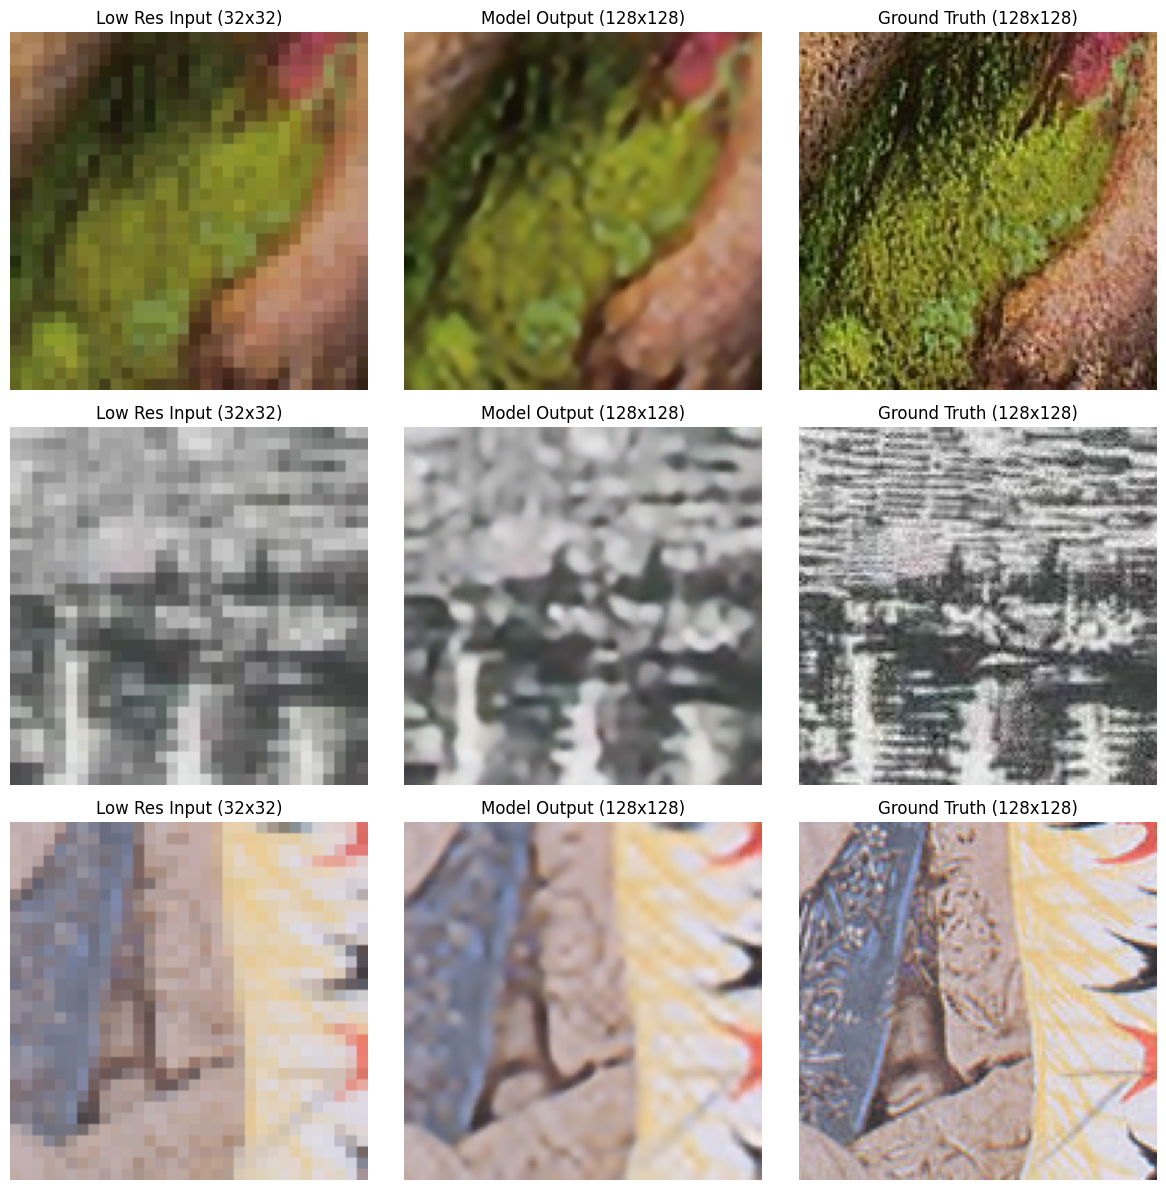

In [29]:
import torch
import matplotlib.pyplot as plt
import time
import numpy as np
from models import SuperResolutionModel


# Load Model
loaded_model = SuperResolutionModel()
# Load weights onto CPU first to be safe, then move to Device
loaded_model.load_state_dict(torch.load('model.pth', map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()

# Get a random batch from validation loader
test_lr, test_hr = next(iter(val_loader))
test_lr = test_lr.to(device)
test_hr = test_hr.to(device)

# Inference Speed Test
start_time = time.time()
with torch.no_grad():
    # Run batch inference
    test_sr = loaded_model(test_lr)
end_time = time.time()

# Calculate per-image time
total_time = end_time - start_time
time_per_img = total_time / test_lr.size(0)
fps = 1 / time_per_img

print(f"\nInference Stats:")
print(f"Batch Size: {test_lr.size(0)}")
print(f"Time per image: {time_per_img:.4f}s")
print(f"FPS: {fps:.2f}")
if time_per_img < 0.033:
    print("Real-time requirement MET (>30 FPS)")
else:
    print("Real-time requirement NOT MET (<30 FPS)")

# Visualization
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    # LR (Nearest neighbor upscale just for display comparison)
    lr_display = torch.nn.functional.interpolate(
        test_lr[i].unsqueeze(0), size=(128,128), mode='nearest'
    ).squeeze(0).cpu().permute(1, 2, 0).clamp(0, 1)

    # Model Output
    sr_display = test_sr[i].cpu().permute(1, 2, 0).clamp(0, 1)

    # Ground Truth
    hr_display = test_hr[i].cpu().permute(1, 2, 0).clamp(0, 1)

    # Plot
    axes[i, 0].imshow(lr_display)
    axes[i, 0].set_title("Low Res Input (32x32)")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(sr_display)
    axes[i, 1].set_title("Model Output (128x128)")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(hr_display)
    axes[i, 2].set_title("Ground Truth (128x128)")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()